In [14]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
import shap
from tqdm import tqdm

ind_hosp = pd.read_parquet("ind_hosp.parquet")
calibrated = joblib.load("lightgbm.pkl")
base_model = calibrated.calibrated_classifiers_[0].estimator

cols_to_drop = [
    "subject_id",
    "hadm_id",
    "dischtime",
    "current_date",
    "target_readmission_30d",
    "los"
]

X = ind_hosp.drop(columns=cols_to_drop)
y = ind_hosp["target_readmission_30d"]

bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)

patient_target = ind_hosp.groupby('subject_id')['target_readmission_30d'].max().reset_index()
patient_target.columns = ['subject_id', 'has_readmission']

train_val_ids, test_ids = train_test_split(
    patient_target['subject_id'],
    test_size=0.2,
    random_state=42,
    stratify=patient_target['has_readmission']
)

train_ids, val_ids = train_test_split(
    train_val_ids,
    test_size=0.125,
    random_state=42,
    stratify=patient_target[patient_target['subject_id'].isin(train_val_ids)]['has_readmission']
)

train_mask = ind_hosp['subject_id'].isin(train_ids)
val_mask = ind_hosp['subject_id'].isin(val_ids)
test_mask = ind_hosp['subject_id'].isin(test_ids)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]
X_sample = X_test

In [15]:
clinical_ranges = {
    'lab_50983_daily': {'low': 135, 'high': 145}, #sodium
    'lab_50971_daily': {'low': 3.5, 'high': 5}, #potassium
    'lab_50902_daily': {'low': 95, 'high': 105}, #chloride
    'lab_50882_daily': {'low': 22, 'high': 32}, #bicarbonate
    'lab_50912_daily': {'low': 0.8, 'high': 1.3}, #creatinine
    'lab_51006_daily': {'low': 8, 'high': 21}, #BUN
    'lab_50931_daily': {'low': 65, 'high': 110}, #glucose
    'lab_50893_daily': {'low': 8.5, 'high': 10.2}, #calcium
    'lab_50868_daily': {'low': 10, 'high': 18}, #anion gap
    'lab_51222_daily': {
        'male': {'low': 13, 'high': 17},
        'female': {'low': 12, 'high': 15}
    }, #hemoglobin
    'lab_51301_daily': {'low': 4, 'high': 10}, #WBC
    'lab_51265_daily': {'low': 150, 'high': 400}, #Platelet Count
    'lab_51221_daily': {
        'male': {'low': 40, 'high': 52},
        'female': {'low': 36, 'high': 47}
    }, #Hematocrit
    'lab_51250_daily': {'low': 80, 'high': 100}, #MCV
    'lab_51277_daily': {'low': 11.5, 'high': 14.5}, #RDW
    'lab_50960_daily': {'low': 1.5, 'high': 2}, #magnesium
    'lab_50970_daily': {'low': 2.7, 'high': 4.5}, #phosphate
    'lab_51248_daily': {'low': 26, 'high': 32}, #MCH
    'lab_51249_daily': {'low': 30, 'high': 35}, #MCHC
    'lab_51279_daily': {
        'male': {'low': 4.5, 'high': 5.9},
        'female': {'low': 4, 'high': 5.2}
    } #RBC
}

def normal_lab_value(col, gender=None):
    ref = clinical_ranges[col]
    if "male" in ref:
        if gender == 1:
            low = ref["male"]["low"]
            high = ref["male"]["high"]
        else:
            low = ref["female"]["low"]
            high = ref["female"]["high"]
    else:
        low = ref["low"]
        high = ref["high"]

    return (low + high) / 2

In [16]:
background_candidates = ind_hosp.loc[
    train_mask &
    (ind_hosp["target_readmission_30d"] == 0)
].copy()

lab_cols = [c for c in X_train.columns if c.startswith("lab_")]

background_candidates["n_labs"] = (
    background_candidates[lab_cols]
    .notna()
    .sum(axis=1)
)

background = (
    background_candidates
    .sort_values(
        ["hadm_id", "n_labs"],
        ascending=[True, False]
    )
    .groupby("hadm_id", group_keys=False)
    .head(1)
)

if len(background) > 100:
    background = background.sample(
        n=100,
        random_state=42
    )

background_X = X.loc[background.index].copy()
bool_cols = background_X.select_dtypes(bool).columns
background_X[bool_cols] = background_X[bool_cols].astype(int)

for col in lab_cols:
    if col not in clinical_ranges:
        continue

    missing = background_X[col].isna()
    male_idx = missing & (background_X["gender_male"] == 1)
    female_idx = missing & (background_X["gender_male"] == 0)
    background_X.loc[male_idx, col] = normal_lab_value(col, 1)
    background_X.loc[female_idx, col] = normal_lab_value(col, 0)

icd_cols = [c for c in X.columns if c.startswith("icd_")]
ccsr_cols = [c for c in X.columns if c.startswith("ccsr_")]
background_X[icd_cols] = background_X[icd_cols].fillna(0)
background_X[ccsr_cols] = background_X[ccsr_cols].fillna(0)

In [17]:
print(background_X.isna().sum().sum())
print(X_sample.isna().sum().sum())

0
1613825


In [18]:
print('Calculating SHAP...')
explainer = shap.TreeExplainer(base_model, data=background_X, feature_perturbation="interventional")
batch_size = 1000
n_batches = int(np.ceil(len(X_sample) / batch_size))

shap_values_list = []

for i in tqdm(range(n_batches), desc="Computing SHAP"):
    start_idx = i * batch_size
    end_idx = min((i + 1) * batch_size, len(X_sample))
    X_batch = X_sample.iloc[start_idx:end_idx]
    
    shap_batch = explainer.shap_values(X_batch)
    shap_values_list.append(shap_batch)

shap_values = np.vstack(shap_values_list)
print(f"SHAP values shape: {shap_values.shape}")
print('Done')

Calculating SHAP...


Computing SHAP: 100%|██████████| 366/366 [1:52:39<00:00, 18.47s/it]


SHAP values shape: (365442, 132)
Done


In [19]:
hadm_ids = ind_hosp.loc[X_sample.index, "hadm_id"].values
shap_df = pd.DataFrame(
    shap_values,
    columns=X_sample.columns,
    index=X_sample.index
)
shap_df["hadm_id"] = hadm_ids

shap_abs_df = shap_df.copy()
feature_cols = X_sample.columns
shap_abs_df[feature_cols] = shap_abs_df[feature_cols].abs()

shap_by_hadm = (
    shap_df
    .groupby("hadm_id")[feature_cols]
    .mean()
)
shap_abs_by_hadm = (
    shap_abs_df
    .groupby("hadm_id")[feature_cols]
    .mean()
)

shap_summary = pd.DataFrame({
    "feature": feature_cols,
    "shap_mean": shap_by_hadm.mean(axis=0).values,
    "shap_abs_mean": shap_abs_by_hadm.mean(axis=0).values,
    "shap_std": shap_by_hadm.std(axis=0).values,
    "shap_abs_std": shap_abs_by_hadm.std(axis=0).values,
}).sort_values(by="shap_abs_mean", ascending=False)

In [20]:
shap_by_hadm_reset = shap_by_hadm.reset_index()
shap_by_hadm_reset.to_csv('shap_matrix_background.csv', index=False)
shap_by_hadm_reset_abs = shap_abs_by_hadm.reset_index()
shap_by_hadm_reset_abs.to_csv('shap_matrix_abs_background.csv', index=False)
shap_summary = shap_summary.reset_index()
shap_summary.to_csv('shap_summary_background.csv', index=False)

### Results

In [21]:
lab_names = {
    '50983': 'Sodium',
    '50971': 'Potassium',
    '50902': 'Chloride',
    '50882': 'Bicarbonate',
    '50912': 'Creatinine',
    '51006': 'BUN',
    '50931': 'Glucose',
    '50893': 'Calcium',
    '50868': 'Anion Gap',
    '51222': 'Hemoglobin',
    '51301': 'WBC',
    '51265': 'Platelet Count',
    '51221': 'Hematocrit',
    '51250': 'MCV',
    '51277': 'RDW',
    '50960': 'Magnesium',
    '50970': 'Phosphate',
    '51248': 'MCH',
    '51249': 'MCHC',
    '51279': 'RBC'
}

icd_names = {
    'I10': 'Essential (primary) hypertension',
    'E785': 'Hyperlipidemia, unspecified',
    'K219': 'Gastroesophageal reflux disease without esophagitis',
    'Z87891': 'Personal history of nicotine dependence',
    'I2510': 'Atherosclerotic heart disease of native coronary artery without angina pectoris',
    'N179': 'Acute kidney failure, unspecified',
    'F329': 'Major depressive disorder, single episode, unspecified',
    'I4891': 'Unspecified atrial fibrillation',
    'Z7901': 'Long term (current) use of anticoagulants',
    'F419': 'Anxiety disorder, unspecified',
    'E119': 'Type 2 diabetes mellitus without complications',
    'E039': 'Hypothyroidism, unspecified',
    'Z794': 'Long term (current) use of insulin',
    'D649': 'Anemia, unspecified',
    'N390': 'Urinary tract infection, site not specified'
}

ccsr_names = {
    'FAC021': 'Personal/family history of disease',
    'FAC025': 'Other specified status',
    'END011': 'Fluid and electrolyte disorders',
    'CIR011': 'Coronary atherosclerosis and other heart disease',
    'END010': 'Disorders of lipid metabolism',
    'CIR007': 'Essential hypertension',
    'END003': 'Diabetes mellitus with complication',
    'CIR019': 'Heart failure',
    'DIG004': 'Esophageal disorders',
    'CIR017': 'Cardiac dysrhythmias',
    'CIR008': 'Hypertension with complications and secondary hypertension',
    'BLD003': 'Aplastic anemia',
    'EXT027': 'External cause codes: place of occurrence of the external cause',
    'GEN002': 'Acute and unspecified renal failure',
    'END009': 'Obesity'
}

def map_feature_name(feature_name):
    if feature_name.startswith('lab_') and feature_name.endswith('_daily'):
        code = feature_name.replace('lab_', '').replace('_daily', '')
        if code in lab_names:
            return f"{lab_names[code]} ({code})"
    elif feature_name.startswith('icd_'):
        code = feature_name.replace('icd_', '')
        if code in icd_names:
            return f"{icd_names[code]} ({code})"
    elif feature_name.startswith('ccsr_'):
        code = feature_name.replace('ccsr_', '')
        if code in ccsr_names:
            return f"{ccsr_names[code]} ({code})"
    return feature_name

In [28]:
import pandas as pd
icd_cols = [col for col in X.columns if col.startswith('icd_')]
ccsr_cols = [col for col in X.columns if col.startswith('ccsr_')]
lab_cols = [col for col in X.columns if col.startswith('lab_') and col.endswith('_daily')]

features_to_analyze = (
    icd_cols +
    ccsr_cols +
    lab_cols +
    [
        'num_diagnoses',
        'num_chronic',
        'comorbidity_score',
        'num_medications_daily',
        'prior_admissions_12mo',
        'cumulative_procedures',
        'cumulative_medications',
        'num_procedures_daily',
        'gender_male',
        'age'
    ]
)

shap_summary = pd.read_csv('shap_summary_background.csv')
shap_summary = shap_summary.sort_values(by="shap_abs_mean", ascending=False)
shap_summary = shap_summary[shap_summary['feature'].isin(features_to_analyze)]
shap_summary['feature'] = shap_summary['feature'].apply(map_feature_name)
shap_summary

,index,feature,shap_mean,shap_abs_mean,shap_std,shap_abs_std
0,59,prior_admissions_12mo,0.063570,0.274429,0.398961,0.296478
1,34,comorbidity_score,0.007422,0.131386,0.157306,0.086831
3,0,age,-0.003736,0.067116,0.083625,0.050032
5,56,RDW (51277),0.024718,0.054719,0.072372,0.054419
6,3,num_chronic,-0.008873,0.054566,0.077986,0.056425
7,2,num_diagnoses,-0.004364,0.043559,0.058520,0.039335
8,37,num_medications_daily,-0.007253,0.037659,0.045825,0.030439
9,36,cumulative_procedures,-0.000221,0.033422,0.044031,0.032567
10,55,Platelet Count (51265),-0.008496,0.032404,0.039982,0.027384
11,48,Sodium (50983),-0.007207,0.031948,0.037118,0.024148


### EDA

In [29]:
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_sample.values,
    feature_names=X_sample.columns.tolist()
)

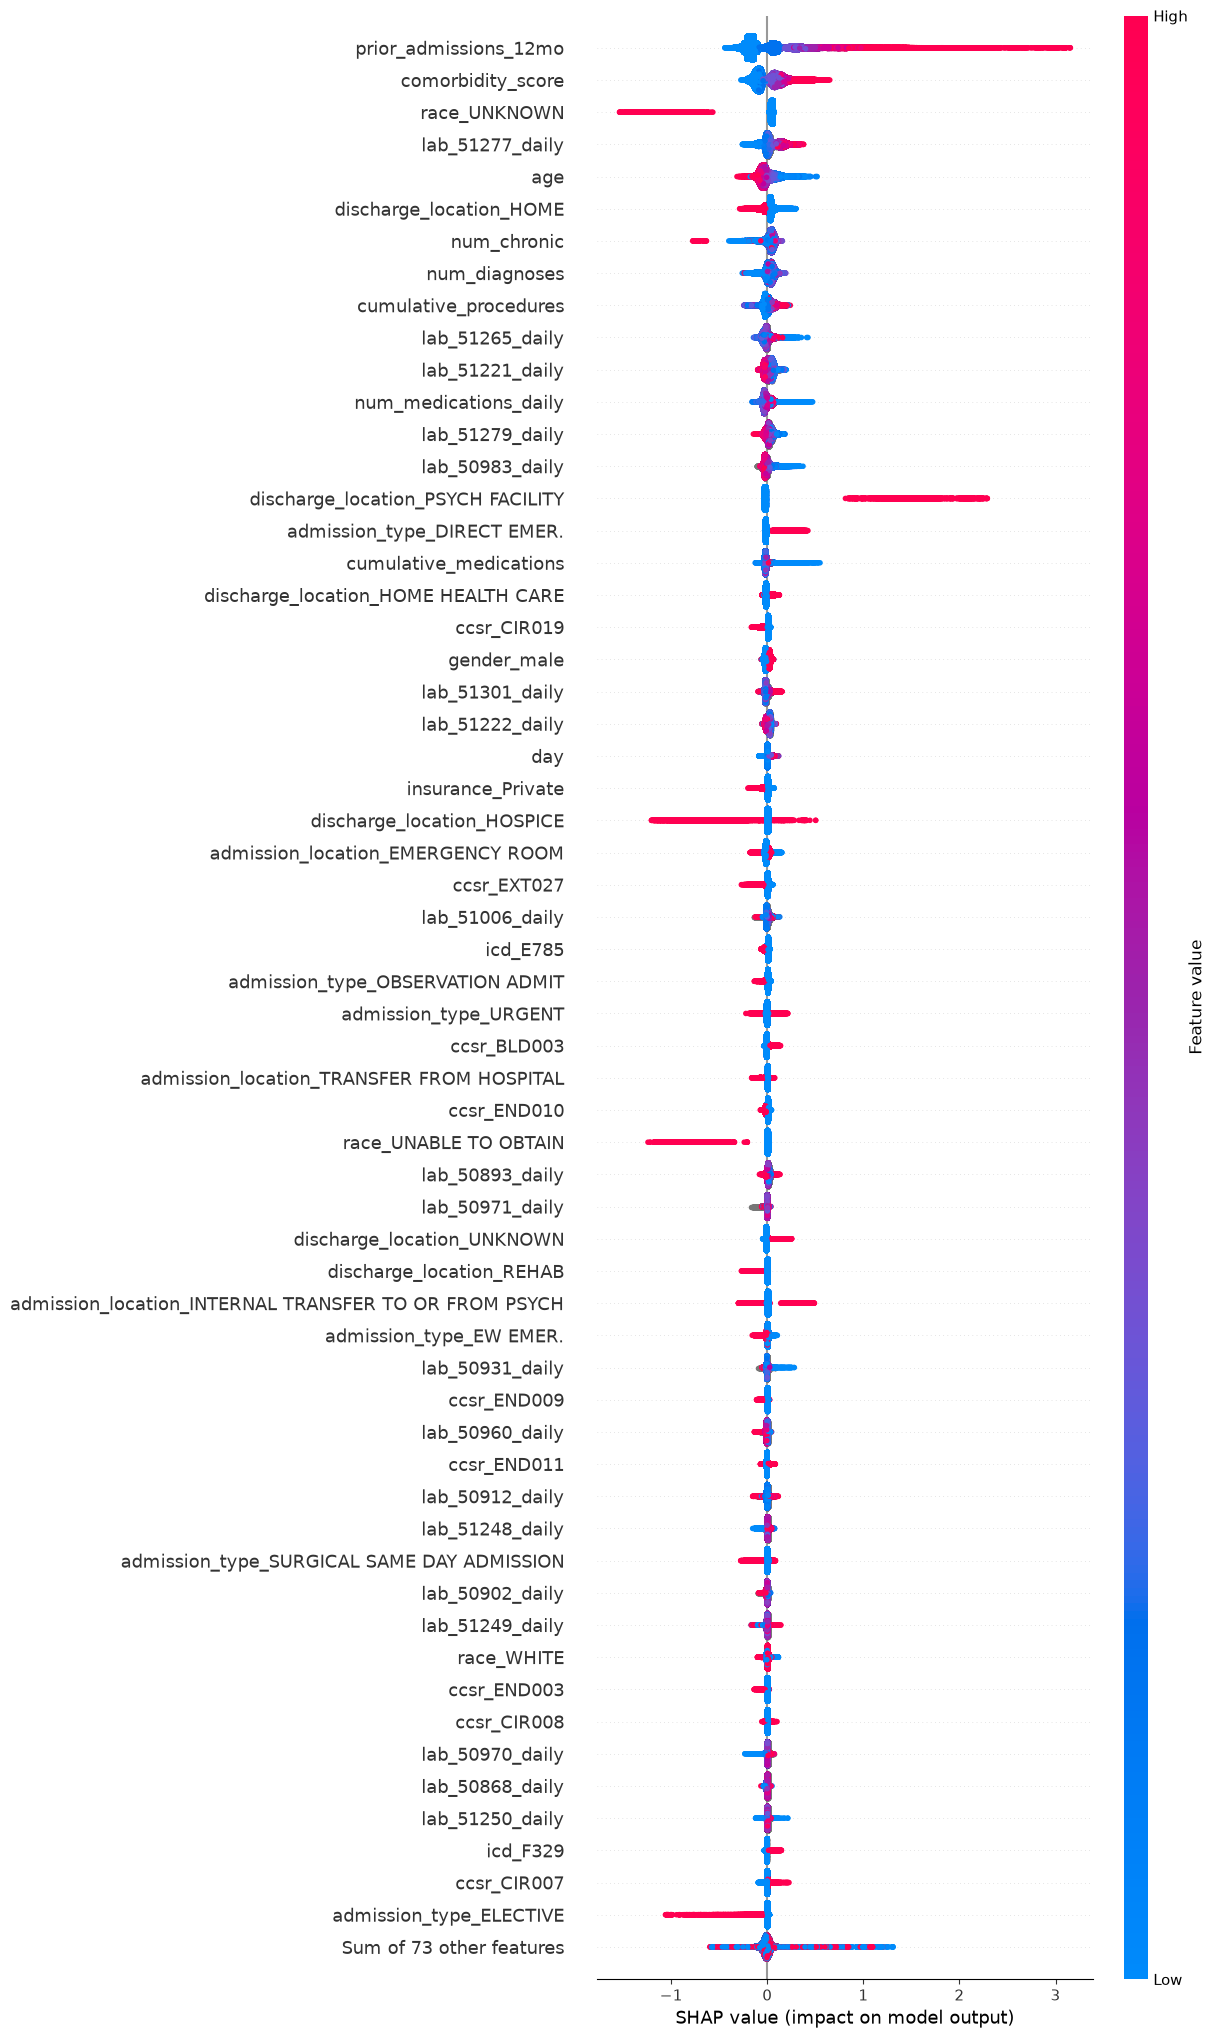

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
shap.plots.beeswarm(explanation, max_display=60)
plt.show()